In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
df = pd.read_csv('Churn_Modelling.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset shape: (10000, 14)
Rows: 10000, Columns: 14


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Stats ===")
df.describe()

=== Missing Values ===
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

=== Data Types ===
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

=== Basic Stats ===


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Churn counts: {0: 7963, 1: 2037}
Churn rate: 20.4%


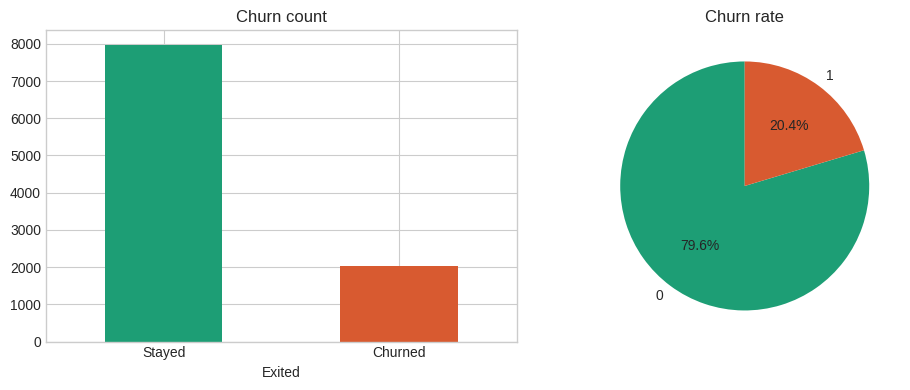

In [ ]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

print("Churn counts:", churn_counts.to_dict())
print("Churn rate: {:.1f}%".format(churn_pct[1]))

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['#1D9E75', '#D85A30'])
axes[0].set_title('Churn count')
axes[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)
churn_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
               colors=['#1D9E75', '#D85A30'], startangle=90)
axes[1].set_title('Churn rate')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

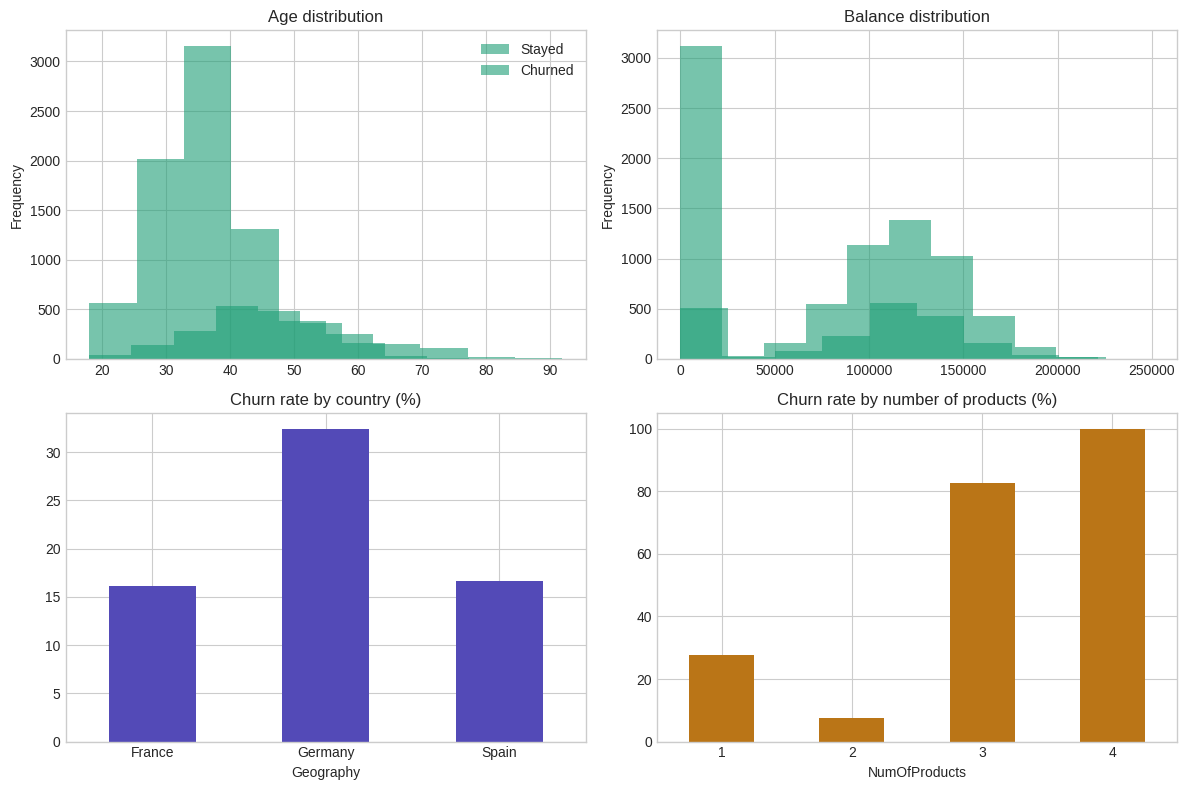

In [ ]:
# Compare churned vs retained customers across key features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age distribution
df.groupby('Exited')['Age'].plot(kind='hist', alpha=0.6,
    ax=axes[0,0], legend=True, color=['#1D9E75', '#D85A30'])
axes[0,0].set_title('Age distribution')
axes[0,0].legend(['Stayed', 'Churned'])

# Balance distribution
df.groupby('Exited')['Balance'].plot(kind='hist', alpha=0.6,
    ax=axes[0,1], color=['#1D9E75', '#D85A30'])
axes[0,1].set_title('Balance distribution')

# Churn by geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', ax=axes[1,0], color='#534AB7')
axes[1,0].set_title('Churn rate by country (%)')
axes[1,0].set_xticklabels(geo_churn.index, rotation=0)

# Churn by number of products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', ax=axes[1,1], color='#BA7517')
axes[1,1].set_title('Churn rate by number of products (%)')
axes[1,1].set_xticklabels(prod_churn.index, rotation=0)

plt.tight_layout()
plt.show()

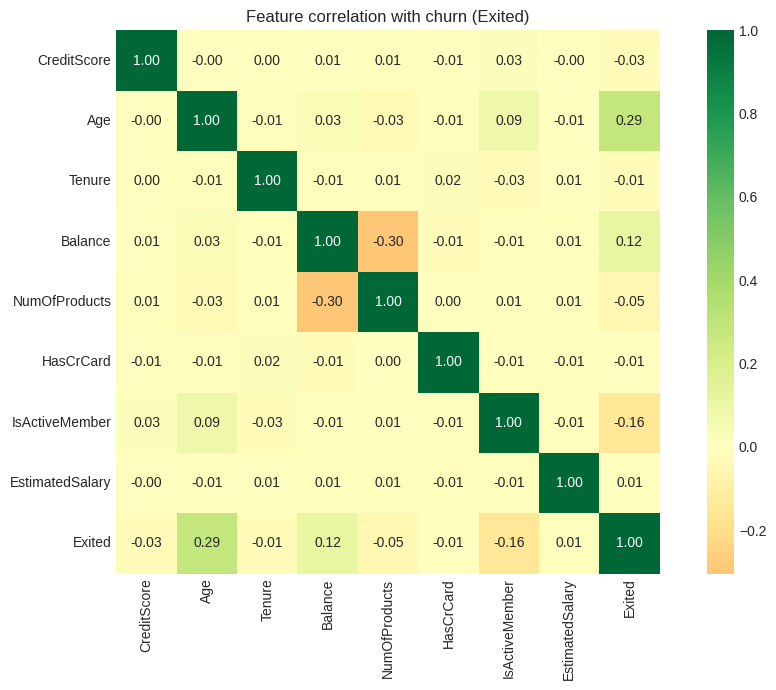

In [ ]:
# Which features are most related to churn?
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                'EstimatedSalary', 'Exited']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True)
plt.title('Feature correlation with churn (Exited)')
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print("Columns after encoding:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")
df.head()

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']

Dataset shape: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features (X): (10000, 11)
Target (y): (10000,)

Feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features so large numbers don't dominate
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 8000
Testing samples:  2000


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train the model
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Stayed', 'Churned']))

=== Logistic Regression ===
Accuracy: 81.10%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.96      0.89      1607
     Churned       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest = many decision trees working together
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Stayed', 'Churned']))

=== Random Forest ===
Accuracy: 86.65%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1607
     Churned       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



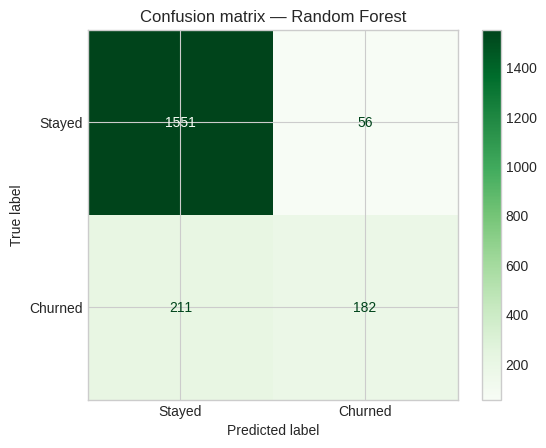


Correctly identified churners: 182
Missed churners:              211


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Greens')
plt.title('Confusion matrix — Random Forest')
plt.show()

print(f"\nCorrectly identified churners: {cm_rf[1][1]}")
print(f"Missed churners:              {cm_rf[1][0]}")

In [ ]:
# Compare both models side by side
print("=" * 40)
print("      MODEL ACCURACY COMPARISON")
print("=" * 40)

lr_acc = accuracy_score(y_test, y_pred_lr) * 100
rf_acc = accuracy_score(y_test, y_pred_rf) * 100

print(f"Logistic Regression : {lr_acc:.2f}%")
print(f"Random Forest       : {rf_acc:.2f}%")
print("-" * 40)

if rf_acc > lr_acc:
    print(f"Random Forest wins by {rf_acc - lr_acc:.2f}%")
else:
    print(f"Logistic Regression wins by {lr_acc - rf_acc:.2f}%")

      MODEL ACCURACY COMPARISON
Logistic Regression : 81.10%
Random Forest       : 86.65%
----------------------------------------
Random Forest wins by 5.55%


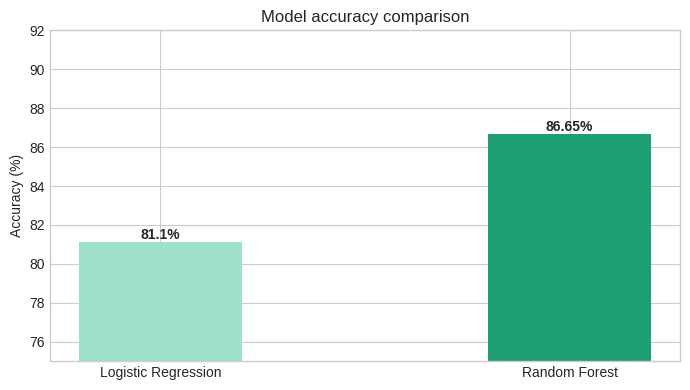

In [ ]:
# Visual comparison of both models
models = ['Logistic Regression', 'Random Forest']
accuracies = [81.10, 86.65]
colors = ['#9FE1CB', '#1D9E75']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=colors, width=0.4)
plt.ylim(75, 92)
plt.ylabel('Accuracy (%)')
plt.title('Model accuracy comparison')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{acc}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

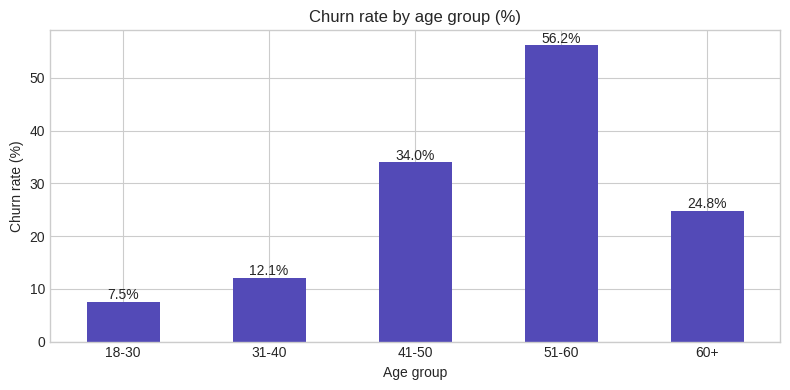

In [ ]:
# Reload original df if needed (before encoding)
df_orig = pd.read_csv('Churn_Modelling.csv')

# Create age groups
df_orig['AgeGroup'] = pd.cut(df_orig['Age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+'])

age_churn = df_orig.groupby('AgeGroup', observed=True)['Exited'].mean() * 100

plt.figure(figsize=(8, 4))
age_churn.plot(kind='bar', color='#534AB7', width=0.5)
plt.title('Churn rate by age group (%)')
plt.xlabel('Age group')
plt.ylabel('Churn rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(age_churn):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

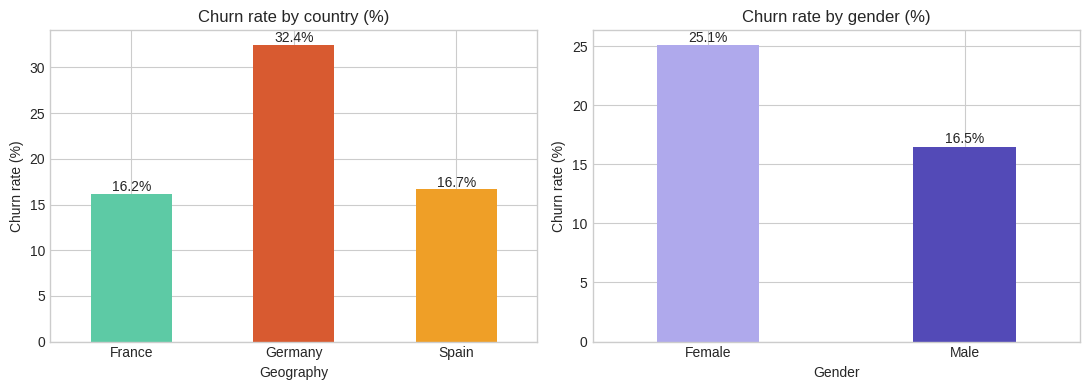

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Churn by country
geo = df_orig.groupby('Geography')['Exited'].mean() * 100
geo.plot(kind='bar', ax=axes[0], color=['#5DCAA5', '#D85A30', '#EF9F27'], width=0.5)
axes[0].set_title('Churn rate by country (%)')
axes[0].set_xticklabels(geo.index, rotation=0)
axes[0].set_ylabel('Churn rate (%)')
for i, v in enumerate(geo):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Churn by gender
gender = df_orig.groupby('Gender')['Exited'].mean() * 100
gender.plot(kind='bar', ax=axes[1], color=['#AFA9EC', '#534AB7'], width=0.4)
axes[1].set_title('Churn rate by gender (%)')
axes[1].set_xticklabels(gender.index, rotation=0)
axes[1].set_ylabel('Churn rate (%)')
for i, v in enumerate(gender):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

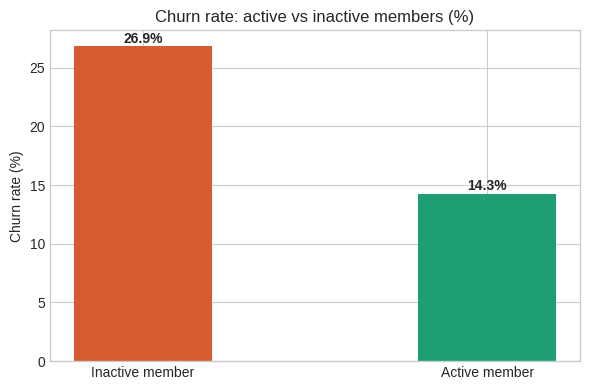

In [ ]:
active = df_orig.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(['Inactive member', 'Active member'],
               active.values, color=['#D85A30', '#1D9E75'], width=0.4)
plt.title('Churn rate: active vs inactive members (%)')
plt.ylabel('Churn rate (%)')

for bar, v in zip(bars, active.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 45)
print("   CUSTOMER CHURN PROJECT — KEY FINDINGS")
print("=" * 45)
print(f"Overall churn rate       : 20.4%")
print(f"Highest churn country    : Germany")
print(f"Most at-risk age group   : 51-60 years")
print(f"Inactive member churn    : ~27% vs ~14%")
print("-" * 45)
print(f"Logistic Regression      : 81.10%")
print(f"Random Forest (AI)       : 86.65%")
print(f"Best model               : Random Forest")
print("=" * 45)

   CUSTOMER CHURN PROJECT — KEY FINDINGS
Overall churn rate       : 20.4%
Highest churn country    : Germany
Most at-risk age group   : 51-60 years
Inactive member churn    : ~27% vs ~14%
---------------------------------------------
Logistic Regression      : 81.10%
Random Forest (AI)       : 86.65%
Best model               : Random Forest
